<a href="https://colab.research.google.com/github/zlkhyr/ScrapingSerambi/blob/main/BPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import torch
import matplotlib.pyplot as plt

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("indolem/indobert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("indolem/indobert-base-uncased", num_labels=30)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31923, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
data = pd.read_excel("/content/drive/MyDrive/semester 8/Magang BPS/fenomena_ekonomi_LU.xlsx",)

In [ ]:
list(data.berita.head(1))

['petani cengkeh di kabupaten simeulue saat ini mengeluh karena rendahnya harga jual cengkeh di wilayah kepulauan itu petani cengkeh menyebutkan harga jual cengkeh tahun ini turun drastis dibanding tahun sebelumnya yang pernah mencapai harga tertinggi rp ribu per kilogram petani cengkeh di simeulue andi kepada serambinewscom selasa mengatakan bahwa harga jual cengkeh di simeulue saat ini tak sampai rp ribu per kilogram sangat turun dari tahun sebelumnya februari lalu saya tanya harga sekilo rp ribu semalam saya tanya lagi sudah turun menjadi rp ribu sekilo ujar andi di sinabang yang turut diiyakan petani cengkeh lainnya harga tersebut lanjut andi merupakan harga di pasar sinabang sementara kalau harga yang dibeli langsung oleh pengepul yang beli langsung dari petani harganya di bawah harga tersebut kalau tahun yang lalu itu sampai rp ribu rp ribu malah ada yang sampai rp ribu sekilo imbuhnya dikatakan jika harga cengkeh terus bertahan dengan harga saat ini maka banyak petani tidak mamp

In [ ]:
len(set(data.kategori)) == model.config.num_labels

True

In [ ]:
label_map = {}

for i in range(len(data.kategori.unique())):
  label_map[data.kategori.unique()[i]] = i

In [ ]:
label_map

{'A1': 0,
 'A2': 1,
 'A3': 2,
 'B1': 3,
 'B2': 4,
 'B3': 5,
 'B4': 6,
 'C1': 7,
 'C2': 8,
 'C3': 9,
 'C4': 10,
 'C5': 11,
 'D': 12,
 'E': 13,
 'F': 14,
 'G': 15,
 'H1': 16,
 'H2': 17,
 'H3': 18,
 'H4': 19,
 'H5': 20,
 'I': 21,
 'J': 22,
 'K': 23,
 'L': 24,
 'MN': 25,
 'O': 26,
 'P': 27,
 'Q': 28,
 'RSTU': 29}

In [ ]:
data.kategori = data.kategori.map(label_map)

In [ ]:
data

,link,berita,kategori
0,https://aceh.tribunnews.com/2020/03/10/harga-c...,petani cengkeh di kabupaten simeulue saat ini ...,0
1,https://aceh.tribunnews.com/2020/03/20/wabah-c...,harga tandan buah segar tbs kelapa sawit di ka...,0
2,https://aceh.tribunnews.com/2020/03/13/bumg-ga...,badan usaha milik gampong bumg ladang sepakat ...,0
3,https://aceh.tribunnews.com/2020/02/06/ini-8-k...,sebelumnya pupuk urea dijatah ton sekarangan n...,0
4,https://aceh.tribunnews.com/2020/01/29/gunakan...,dari sebanyak delapan kecamatan di pidie tanam...,0
...,...,...,...
752,https://news.detik.com/berita/d-3983782/sambut...,komisi pemilihan umum kpu mengadakan pagelaran...,29
753,http://banjarmasin.tribunnews.com/2018/05/29/p...,usaha jasa laundry selama ramadan ini alami pe...,29
754,https://money.kompas.com/read/2019/10/02/05513...,jumlah kunjungan wisawatan mancanegara wisman ...,29
755,https://www.bola.com/indonesia/read/4057716/ka...,september menjadi periode sibuk bagi timnas in...,29


In [ ]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    data['berita'], data['kategori'],
    test_size=0.3, random_state=42, stratify=data['kategori']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size=0.5, random_state=42, stratify=temp_labels
)


In [ ]:
def preprocess(texts, labels, shuffle):

  encoding = tokenizer(
      texts.tolist(),
      padding=True,
      truncation=True,
      max_length=model.config.max_position_embeddings,
      return_tensors="pt"
  )

  tensorLabels = torch.tensor(labels.tolist(), dtype=torch.long)
  tensorDataset = TensorDataset(encoding['input_ids'], encoding['attention_mask'], tensorLabels)
  dataloader = DataLoader(tensorDataset, batch_size=16, shuffle=shuffle)
  return dataloader

In [ ]:
train_dataloader = preprocess(train_texts, train_labels, True)
val_dataloader = preprocess(val_texts, val_labels, False)
# test_dataloader = preprocess(test_texts, test_labels, False)

In [ ]:
from torch.optim import AdamW
from torch import nn
from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Code running di: {device}")

Code running di: cuda


In [ ]:
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31923, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
optimizer = AdamW(model.parameters(), lr=1e-5)
loss_fn = nn.CrossEntropyLoss()

In [ ]:
history = {
        'train_loss':[],
        'val_loss':[],
        'train_acc':[],
        'val_acc':[]
    }

In [ ]:
for batch in train_dataloader:
  print(batch)
  break

[tensor([[    3,  1766,  8199,  ...,     0,     0,     0],
        [    3, 10121,  8084,  ...,  3393,  1684,     4],
        [    3,  6046,  4129,  ..., 24371,  3286,     4],
        ...,
        [    3,  2661,  2970,  ...,     0,     0,     0],
        [    3, 12040,  8961,  ...,     0,     0,     0],
        [    3, 11987,  2627,  ...,     0,     0,     0]]), tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]]), tensor([ 5, 21, 12, 22, 22, 11, 21, 11,  1, 19, 12, 24, 10,  4, 17, 24])]


In [ ]:
epochs = 10
for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        correct_train = 0
        total_train = 0

        for batch in tqdm(train_dataloader, desc=f"Epoch {epoch + 1}/{epochs} [Train]", leave=False):
            input_ids, attention_mask, labels = batch
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)

            outputs = model(input_ids, attention_mask)
            loss = loss_fn(outputs.logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            _, predicted = torch.max(outputs.logits.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        avg_train_loss = total_train_loss / len(train_dataloader)
        train_accuracy = correct_train / total_train
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_accuracy)

        model.eval()
        total_val_loss = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for batch in tqdm(val_dataloader, desc=f"Epoch {epoch + 1}/{epochs} [Validation]", leave=False):
                input_ids, attention_mask, labels = batch
                input_ids = input_ids.to(device)
                attention_mask = attention_mask.to(device)
                labels = labels.to(device)

                outputs = model(input_ids, attention_mask)
                loss = loss_fn(outputs.logits, labels)

                total_val_loss += loss.item()
                _, predicted = torch.max(outputs.logits.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        avg_val_loss = total_val_loss / len(val_dataloader)
        val_accuracy = correct_val / total_val
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_accuracy)

        print(f"Epoch [{epoch + 1}/{epochs}], Loss:{avg_train_loss:.4f}, Validation Loss:{avg_val_loss:.4f}, Accuracy:{train_accuracy:.2f}, Validation Accuracy:{val_accuracy:.2f}")

Epoch [1/10], Loss:3.3522, Validation Loss:3.2622, Accuracy:0.10, Validation Accuracy:0.15


Epoch [2/10], Loss:3.1692, Validation Loss:3.0958, Accuracy:0.16, Validation Accuracy:0.21


Epoch [3/10], Loss:2.9525, Validation Loss:2.8044, Accuracy:0.29, Validation Accuracy:0.43


Epoch [4/10], Loss:2.6599, Validation Loss:2.4965, Accuracy:0.55, Validation Accuracy:0.59


Epoch [5/10], Loss:2.3068, Validation Loss:2.1768, Accuracy:0.65, Validation Accuracy:0.67


Epoch [6/10], Loss:1.9667, Validation Loss:1.8868, Accuracy:0.72, Validation Accuracy:0.70


Epoch [7/10], Loss:1.6810, Validation Loss:1.6159, Accuracy:0.80, Validation Accuracy:0.75


Epoch [8/10], Loss:1.4476, Validation Loss:1.4226, Accuracy:0.84, Validation Accuracy:0.77


Epoch [9/10], Loss:1.1925, Validation Loss:1.2647, Accuracy:0.89, Validation Accuracy:0.80


Epoch [10/10], Loss:1.0304, Validation Loss:1.1192, Accuracy:0.92, Validation Accuracy:0.80


In [ ]:
def learning_curve(history, mode='loss'):
  plt.figure()
  if mode == 'loss':
    plt.plot(history['train_loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
  elif mode == 'acc':
    plt.plot(history['train_acc'], label='Training Accuracy')
    plt.plot(history['val_acc'], label='Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title(f'Learning Curve: {mode}')
  plt.legend()
  plt.grid(True)
  plt.show()

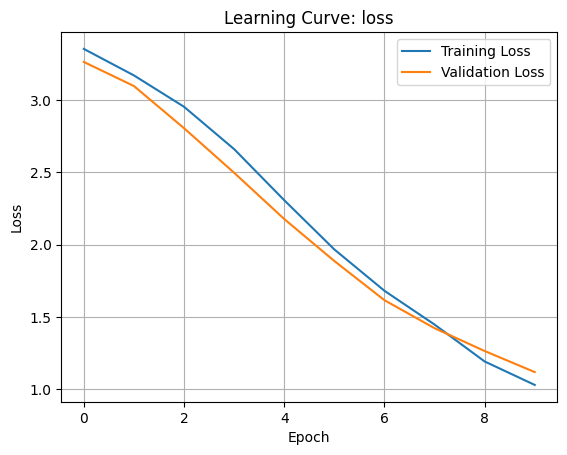

In [ ]:
learning_curve(history, 'loss')

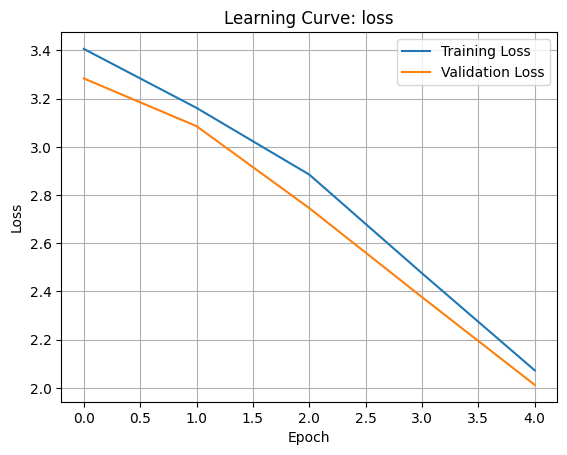

In [ ]:
learning_curve(history, 'loss')

In [ ]:
test_dataloader = preprocess(test_texts, test_labels, False)

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
  for batch in tqdm(test_dataloader, desc=f"Epoch {epoch + 1}/{epochs} [Validation]", leave=False):
    input_ids, attention_mask, labels = batch
    input_ids = input_ids.to(device)
    attention_mask = attention_mask.to(device)
    labels = labels.to(device)

    outputs = model(input_ids, attention_mask)
    _, predicted = torch.max(outputs.logits.data, 1)

    all_preds.extend(predicted.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.50      0.67      0.57         3
           1       0.75      0.75      0.75         4
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         5
           4       0.80      1.00      0.89         4
           5       0.67      1.00      0.80         4
           6       1.00      0.75      0.86         4
           7       0.67      0.50      0.57         4
           8       1.00      0.67      0.80         3
           9       1.00      0.25      0.40         4
          10       0.33      0.25      0.29         4
          11       0.00      0.00      0.00         3
          12       0.80      1.00      0.89         4
          13       0.57      1.00      0.73         4
          14       1.00      1.00      1.00         2
          15       0.71      1.00      0.83         5
          16       0.75      0.75      0.75         4
          17       1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
